# Integrative Challenge: Activity 1
## Computational and visual representation of the logistics environment

Virtual distribution center (inspired by RoboArena 4.0 by e80 Group)

Name: Brian Roberto Gómez Martínez  Student ID: A00841404  Team: .gitignore


## 0. Dependencies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch, FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

plt.rcParams["figure.dpi"] = 110

## 1. Coordinate system

In [ ]:
FREE, WALL, PRODUCTION, RACK, DOCK, CHARGER, OBSTACLE = range(7)

CODE = {"wall": WALL, "production": PRODUCTION, "rack": RACK,
        "dock": DOCK, "charger": CHARGER, "obstacle": OBSTACLE}

## 2. Layout parameters

In [ ]:
P = dict(
    width=48, height=30,

    n_lines=3, line_x=2, line_y0=4, line_w=9, line_h=3, line_pitch=8, line_pallets=3,

    rack_x0=18, rack_y0=3, rack_cols=3, rack_rows=2, rack_w=4, rack_h=10,
    aisle_x=3, aisle_y=4, slot_pitch=2,

    n_docks=3, dock_y0=3, dock_w=4, dock_h=5, dock_pitch=9, dock_pallets=2,

    n_chargers=3, charger_x0=9, charger_y=1, charger_w=2, charger_h=2, charger_pitch=4,

    columns=[(14, 8), (14, 15), (14, 22), (38, 8), (38, 15), (38, 22)],
    zones=[(1, 1, 6, 2, "Maintenance room"), (20, 27, 6, 2, "Offices / QC")],
)

## 3. Building the environment

In [ ]:
def build(P):
    elements, pallets = [], []
    add = lambda i, k, x, y, w, h, lab="": elements.append(
        dict(id=i, kind=k, x=x, y=y, w=w, h=h, label=lab))
    slot = lambda i, g, x, y: pallets.append(dict(id=i, group=g, x=x, y=y))

    add("WALL-S", "wall", 0, 0, P["width"], 1)
    add("WALL-N", "wall", 0, P["height"] - 1, P["width"], 1)
    add("WALL-W", "wall", 0, 1, 1, P["height"] - 2)
    add("WALL-E", "wall", P["width"] - 1, 1, 1, P["height"] - 2)

    for i in range(P["n_lines"]):
        y = P["line_y0"] + i * P["line_pitch"]
        add(f"PL-{i+1:02d}", "production", P["line_x"], y, P["line_w"], P["line_h"])
        for k in range(P["line_pallets"]):
            slot(f"PLB-{i+1:02d}-{k+1}", "production", P["line_x"] + P["line_w"], y + k)

    for col in range(P["rack_cols"]):
        for row in range(P["rack_rows"]):
            x = P["rack_x0"] + col * (P["rack_w"] + P["aisle_x"])
            y = P["rack_y0"] + row * (P["rack_h"] + P["aisle_y"])
            rid = f"R-{col+1}{row+1}"
            add(rid, "rack", x, y, P["rack_w"], P["rack_h"])
            for side, sx in (("W", x), ("E", x + P["rack_w"] - 1)):
                for k, sy in enumerate(range(y, y + P["rack_h"], P["slot_pitch"])):
                    slot(f"{rid}-{side}{k+1}", "rack", sx, sy)

    dx = P["width"] - 1 - P["dock_w"]
    for i in range(P["n_docks"]):
        y = P["dock_y0"] + i * P["dock_pitch"]
        add(f"DK-{i+1:02d}", "dock", dx, y, P["dock_w"], P["dock_h"])
        for k in range(P["dock_pallets"]):
            slot(f"DKS-{i+1:02d}-{k+1}", "dock", dx - 2, y + 1 + 2 * k)

    for i in range(P["n_chargers"]):
        add(f"CH-{i+1:02d}", "charger", P["charger_x0"] + i * P["charger_pitch"],
            P["charger_y"], P["charger_w"], P["charger_h"])

    for x, y in P["columns"]:
        add(f"COL-{x}-{y}", "obstacle", x, y, 1, 1)
    for j, (x, y, w, h, lab) in enumerate(P["zones"]):
        add(f"OBS-{j+1:02d}", "obstacle", x, y, w, h, lab)

    grid = np.full((P["height"], P["width"]), FREE, dtype=np.int8)
    for e in elements:
        grid[e["y"]:e["y"] + e["h"], e["x"]:e["x"] + e["w"]] = CODE[e["kind"]]

    return elements, pallets, grid

In [ ]:
elements, pallets, grid = build(P)
walkable = grid == FREE

print(f"Space: {P['width']} x {P['height']} m")
print(f"Traversable area: {walkable.sum()} m^2 "
      f"({walkable.mean():.0%} of the floor)")
print(f"Elements: {len(elements)}  ·  pallet positions: {len(pallets)}")
print("\nExample element E_i = (x, y, w, h):", elements[5])

Space: 48 x 30 m
Traversable area: 865 m^2 (60% of the floor)
Elements: 27  ·  pallet positions: 75

Example element E_i = (x, y, w, h): {'id': 'PL-02', 'kind': 'production', 'x': 2, 'y': 12, 'w': 9, 'h': 3, 'label': ''}


## 4. Visual representation


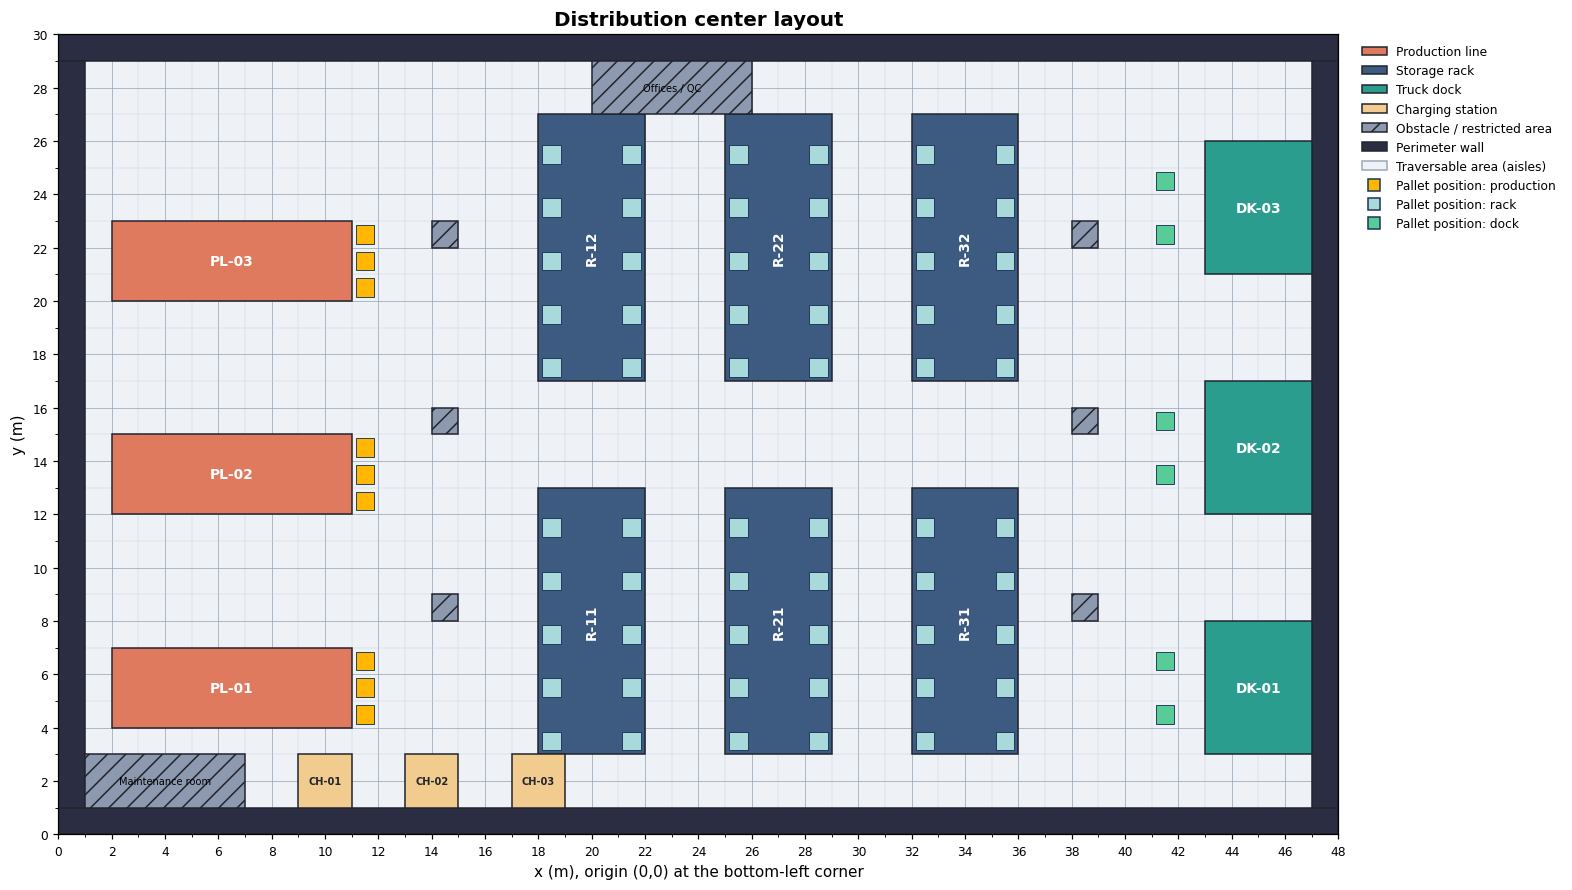

In [ ]:
COLORS = {"production": "#e07a5f", "rack": "#3d5a80", "dock": "#2a9d8f",
          "charger": "#f2cc8f", "obstacle": "#8d99ae", "wall": "#2b2d42"}
NAMES = {"production": "Production line", "rack": "Storage rack", "dock": "Truck dock",
         "charger": "Charging station", "obstacle": "Obstacle / restricted area",
         "wall": "Perimeter wall"}
PALLET_COLORS = {"production": "#ffb703", "rack": "#a8dadc", "dock": "#57cc99"}
FREE_COLOR = "#eef2f7"

FLOWS = {"Production line -> Rack / Truck dock": "#d00000",
         "Rack -> Truck dock": "#3a0ca3",
         "Truck dock -> Rack": "#008000"}


def plot(elements, pallets, grid, P, flows=None, title="Distribution center", path=None):
    fig, ax = plt.subplots(figsize=(15, 8.2))
    dim = .35 if flows else 1.0

    ax.imshow(np.where(grid == FREE, 0, np.nan), cmap=ListedColormap([FREE_COLOR]),
              extent=(0, P["width"], 0, P["height"]), origin="lower", zorder=0)

    for e in elements:
        ax.add_patch(Rectangle((e["x"], e["y"]), e["w"], e["h"], zorder=2, alpha=dim,
                               facecolor=COLORS[e["kind"]], edgecolor="#22252e", lw=1,
                               hatch="//" if e["kind"] == "obstacle" else None))
        if not flows and e["kind"] in ("production", "rack", "dock", "charger"):
            small = e["kind"] == "charger"
            ax.text(e["x"] + e["w"] / 2, e["y"] + e["h"] / 2, e["id"], zorder=4,
                    ha="center", va="center", fontweight="bold",
                    color="#22252e" if small else "white", fontsize=6.5 if small else 9,
                    rotation=90 if e["kind"] == "rack" else 0)
        if not flows and e["label"]:
            ax.text(e["x"] + e["w"] / 2, e["y"] + e["h"] / 2, e["label"], zorder=4,
                    ha="center", va="center", fontsize=6.5)

    for s in pallets:
        ax.add_patch(Rectangle((s["x"] + .15, s["y"] + .15), .7, .7, zorder=3, alpha=dim,
                               facecolor=PALLET_COLORS[s["group"]], edgecolor="#1d3557", lw=.6))

    handles = []
    if flows:
        pos = {s["id"]: (s["x"] + .5, s["y"] + .5) for s in pallets}
        for a, b, kind, rad in flows:
            ax.add_patch(FancyArrowPatch(pos[a], pos[b], color=FLOWS[kind], zorder=6,
                                         connectionstyle=f"arc3,rad={rad}",
                                         arrowstyle="-|>", mutation_scale=16, lw=2))
        handles = [Line2D([], [], color=v, lw=2.5, label=k) for k, v in FLOWS.items()]

    handles += [Patch(facecolor=COLORS[k], edgecolor="#22252e", label=NAMES[k],
                      hatch="//" if k == "obstacle" else None) for k in NAMES]
    handles.append(Patch(facecolor=FREE_COLOR, edgecolor="#9aa8b8",
                         label="Traversable area (aisles)"))
    handles += [Line2D([], [], marker="s", ls="", markerfacecolor=v, markeredgecolor="#1d3557",
                       markersize=8, label=f"Pallet position: {k}")
                for k, v in PALLET_COLORS.items()]

    ax.set_xlim(0, P["width"]); ax.set_ylim(0, P["height"]); ax.set_aspect("equal")
    ax.set_xticks(range(0, P["width"] + 1, 2)); ax.set_yticks(range(0, P["height"] + 1, 2))
    ax.set_xticks(range(P["width"] + 1), minor=True)
    ax.set_yticks(range(P["height"] + 1), minor=True)
    ax.grid(which="minor", color="#c9d3df", lw=.3, zorder=1)
    ax.grid(which="major", color="#9aa8b8", lw=.5, zorder=1)
    ax.set_xlabel("x (m), origin (0,0) at the bottom-left corner"); ax.set_ylabel("y (m)")
    ax.tick_params(labelsize=8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8,
              frameon=False)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


plot(elements, pallets, grid, P, title="Distribution center layout",
     path="logistics_environment.png")
plt.show()

## 5. Logistics flows


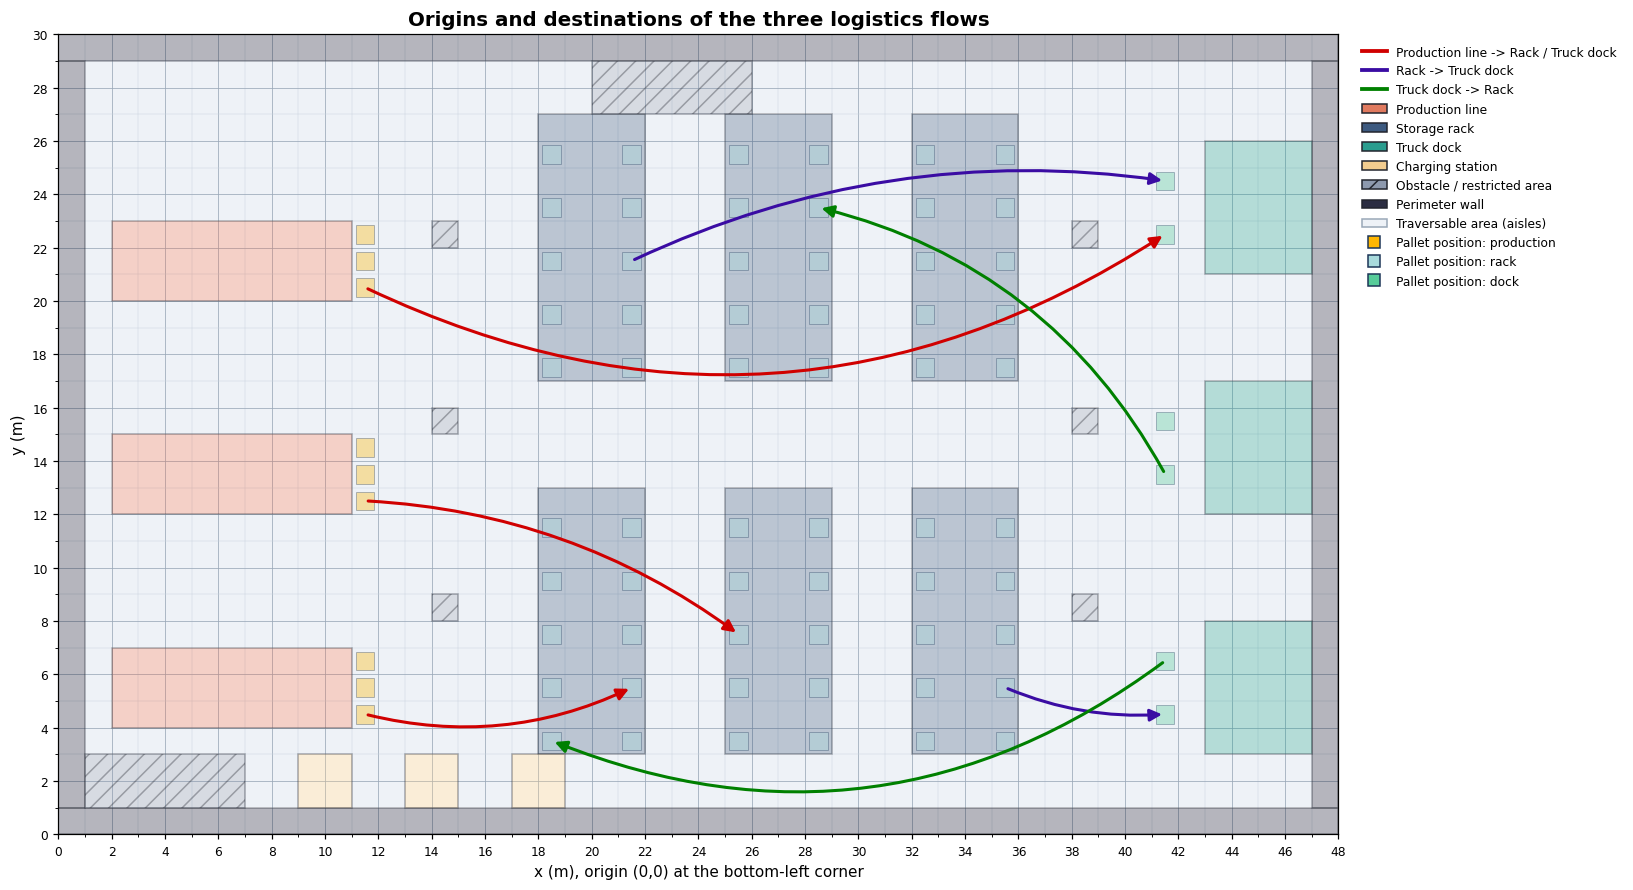

In [ ]:
flows = [
    ("PLB-01-1", "R-11-E2", "Production line -> Rack / Truck dock",  .18),
    ("PLB-02-1", "R-21-W3", "Production line -> Rack / Truck dock", -.15),
    ("PLB-03-1", "DKS-03-1", "Production line -> Rack / Truck dock",  .28),
    ("R-12-E3",  "DKS-03-2", "Rack -> Truck dock",                   -.15),
    ("R-31-E2",  "DKS-01-1", "Rack -> Truck dock",                    .12),
    ("DKS-02-1", "R-22-E4",  "Truck dock -> Rack",                    .22),
    ("DKS-01-2", "R-11-W1",  "Truck dock -> Rack",                   -.28),
]

plot(elements, pallets, grid, P, flows=flows,
     title="Origins and destinations of the three logistics flows",
     path="logistics_flows.png")
plt.show()

## 6. The layout is parametric

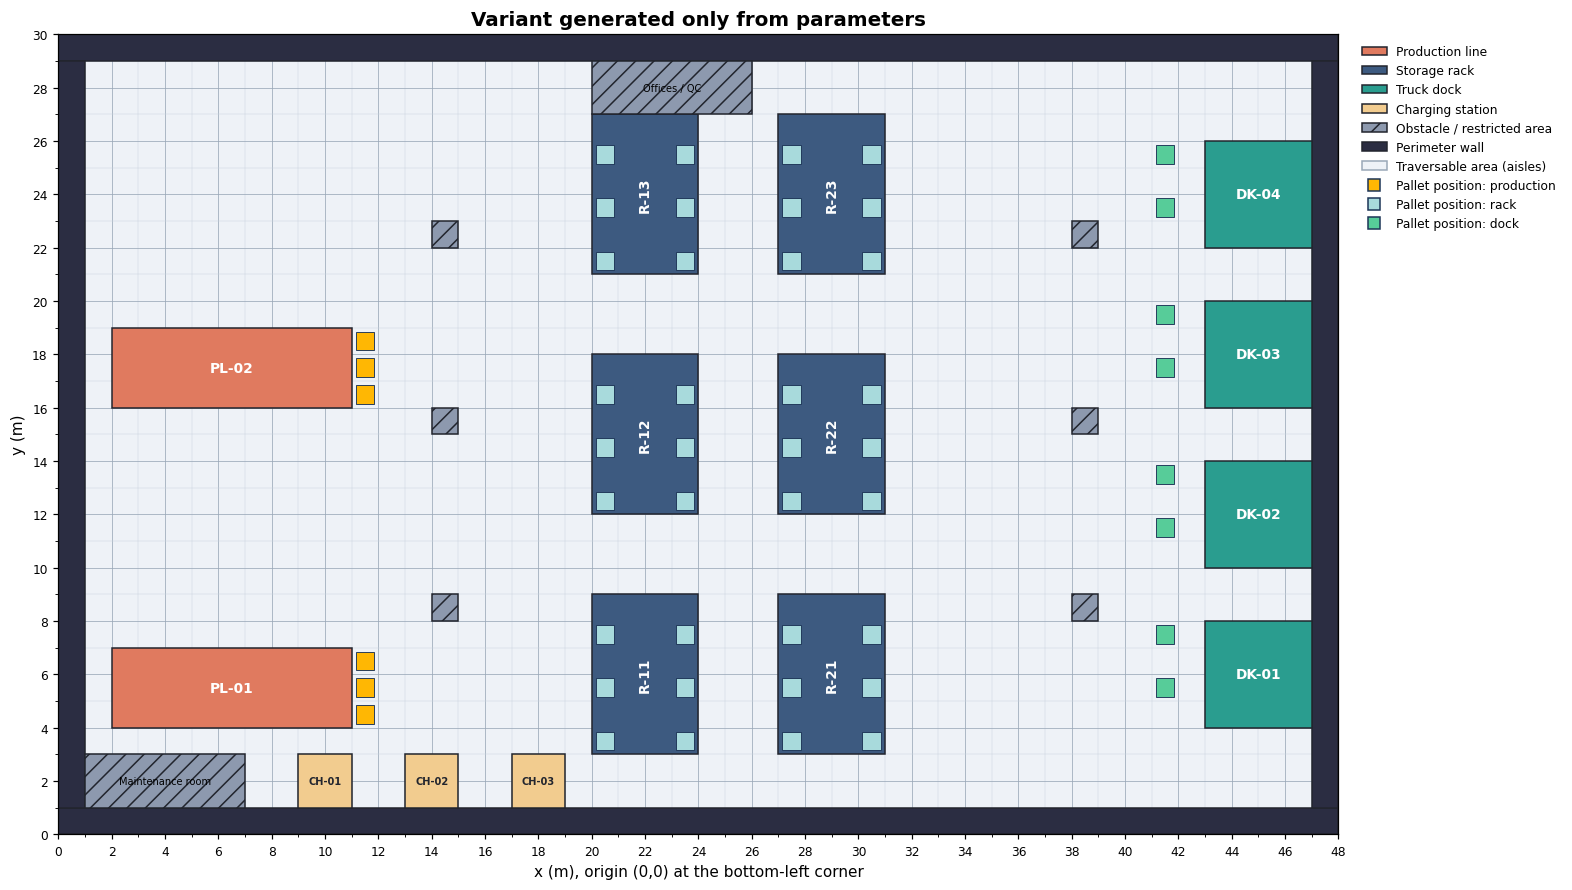

In [ ]:
P_alt = dict(P, rack_x0=20, rack_cols=2, rack_rows=3, rack_h=6, aisle_y=3,
             n_lines=2, line_pitch=12, n_docks=4, dock_h=4, dock_pitch=6, dock_y0=4)

plot(*build(P_alt), P_alt, title="Variant generated only from parameters")
plt.show()

---

# Brief Analysis

**1. How the environment was represented**

Used two structures from a parameter dictionary P. First, a list of dicts with id, type, x, y, width, and height to send it straight to Unity. Second, an occupancy grid in numpy int8 where each cell has a number based on what is there, so walkable = grid == FREE quickly pulls where you can move. Pallet spots are in a separate list since they are points inside zones and not solid blocks.

**2. Elements included**

Perimeter wall, 3 production lines with 3 output pallets each, 6 racks in a 3x2 grid with 60 pallet spots in total, 3 docks on the east wall with 2 staging spots each, 3 chargers, open aisles, and obstacles like six 1x1 columns, the maintenance room, and the offices.

**3. Changes made compared to the class example**

The map was changed to 48x30 meters with 1-meter cells. Racks are in a 3x2 grid with a 4m cross aisle and 3m side aisles instead of just one row, 3 separate lines on the west, docks moved to the east with their own maneuvering room, chargers on the bottom aisle so they do not block traffic, and columns inside the aisles. Plus everything is parametric, so changing the input data generates other variants without touching the code.

**4. Why this layout was chosen**

It follows a clean west-to-east flow (production on the west, storage in the middle, shipping on the east) so all flows share the same main direction and do not cross as much. Vertical racks create north-south aisles connected by a middle cross aisle, so there are always at least two alternative routes to any point to prevent deadlocks when multiple AGVs run at once. Chargers are down at the bottom out of heavy traffic, and staging separates the AGVs from the trucks.

**5. Traversable areas and obstacles**

Everything that is not an aisle is marked in the matrix with its type. Traversable space is strictly where grid == FREE and everything else is an obstacle (walls, racks, lines, docks, columns). The AGV never drives into a zone, it always operates from the adjacent aisle cell. In the drawing, walkable space is the light background with the grid, and gray hatched areas are obstacles.

**6. Origins and destinations for the 3 flows**

* Line to Rack or Dock: starts at production outputs at x=11 and goes to any rack spot or dock staging at x=41.
* Rack to Dock: starts at the 60 rack spots and goes to the 6 dock staging points.
* Dock to Rack: starts at dock staging and goes to the racks.
Each pallet already has its group assigned so they are easy to filter.

**7. Key elements for AGV logic**

The occupancy grid and the walkable mask because they feed straight into A*, MDPs, or Q-tables. The cells adjacent to pallets, since the AGV stops next to the cargo instead of on top of it, making that neighboring cell the actual navigation goal. Aisle widths and alternate routes to tell if two AGVs can pass each other or if you need to reserve track segments. Chargers for handling low-battery logic, and the 1m cell size that fixes movement cost and state space size.

---

# Integrative Challenge: Activity 2



## 7. AGV Agent Model, Missions and Pallet States

Each AGV keeps its own state $s_i=(position_i, battery_i, status_i, mission_i)$ with $Status_i \in \{Available, ToPickup, Transporting, Charging\}$, now implemented as an `agentpy.Agent` living inside an `agentpy.Model` (per the professor's suggestion), instead of a plain dict. Each mission is $M_k=(O_k, D_k, P_k, S_k)$, reusing the pallet slots already placed by the environment (the same seven flows used in section 5 above), so "Rack != Pallet" still holds.


In [ ]:
!pip install agentpy

In [ ]:
import random
from collections import deque
import pandas as pd
import agentpy as ap
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

random.seed(7)

missions_preview = [dict(id=f"M{idx+1:02d}", origin=o, destination=d, status="Pending")
                    for idx, (o, d, kind, _rad) in enumerate(flows)]

print(f"{len(missions_preview)} transportation missions created from the logistics flows above:")
for m in missions_preview:
    print(" ", m)


7 transportation missions created from the logistics flows above:
  {'id': 'M01', 'origin': 'PLB-01-1', 'destination': 'R-11-E2', 'status': 'Pending'}
  {'id': 'M02', 'origin': 'PLB-02-1', 'destination': 'R-21-W3', 'status': 'Pending'}
  {'id': 'M03', 'origin': 'PLB-03-1', 'destination': 'DKS-03-1', 'status': 'Pending'}
  {'id': 'M04', 'origin': 'R-12-E3', 'destination': 'DKS-03-2', 'status': 'Pending'}
  {'id': 'M05', 'origin': 'R-31-E2', 'destination': 'DKS-01-1', 'status': 'Pending'}
  {'id': 'M06', 'origin': 'DKS-02-1', 'destination': 'R-22-E4', 'status': 'Pending'}
  {'id': 'M07', 'origin': 'DKS-01-2', 'destination': 'R-11-W1', 'status': 'Pending'}


## 8. AGV Agent (`agentpy.Agent`) and Multiple AGVs

Each AGV is now an `agentpy.Agent` subclass, so its state and behaviour live together instead of being carried by hand in a dict. At least four independent instances are created inside the model below (section 10), spawned near the charging stations already defined in the environment -- each gets its own free cell, which is also where the AGVs-spawning-on-top-of-each-other bug was coming from (see section 12 of the analysis).


In [ ]:
N_AGV = 4
B_MAX, B_THRESHOLD = 100.0, 45.0     # battery capacity / recharge threshold
C_D, R_C = 0.6, 10.0                 # consumption per cell moved / charge rate per step
WD, WB, WL = 2.0, 0.5, 20.0          # negotiation weights: distance, battery, workload

def nearest_walkable(p, walkable):
    x0, y0 = p
    H, W = walkable.shape
    if 0 <= y0 < H and 0 <= x0 < W and walkable[y0, x0]:
        return p
    dq, seen = deque([p]), {p}
    while dq:
        x, y = dq.popleft()
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = x + dx, y + dy
            if 0 <= nx < W and 0 <= ny < H and (nx, ny) not in seen:
                if walkable[ny, nx]:
                    return (nx, ny)
                seen.add((nx, ny)); dq.append((nx, ny))
    return p

def nearest_free_cell(p, walkable, taken):
    """Like nearest_walkable, but also skips cells another AGV already occupies -- this
    is what stops two AGVs from spawning stacked on the exact same charger cell."""
    x0, y0 = p
    H, W = walkable.shape
    if 0 <= y0 < H and 0 <= x0 < W and walkable[y0, x0] and (x0, y0) not in taken:
        return (x0, y0)
    dq, seen = deque([p]), {p}
    while dq:
        x, y = dq.popleft()
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = x + dx, y + dy
            if 0 <= nx < W and 0 <= ny < H and (nx, ny) not in seen:
                if walkable[ny, nx] and (nx, ny) not in taken:
                    return (nx, ny)
                seen.add((nx, ny)); dq.append((nx, ny))
    return p


class AGV(ap.Agent):
    """One AGV's state: s_i = (position_i, battery_i, status_i, mission_i)."""

    def setup(self):
        self.status = "Available"        # Available | ToPickup | Transporting | Charging
        self.mission = None
        self.path, self.path_idx = [], 0
        self.completed, self.distance = 0, 0
        self.charger = None
        self.battery = random.choice([55.0, 70.0, 85.0, 100.0])
        self.wait_streak = 0             # consecutive ticks blocked by another AGV

    @property
    def label(self):
        return f"AGV-{self.id}"

    def bid(self, origin_xy):
        """Utility U_i,k = -w_d*D + w_b*B_i - w_l*L_i (distance, battery, workload)."""
        D = abs(self.x - origin_xy[0]) + abs(self.y - origin_xy[1])
        return -WD * D + WB * self.battery - WL * (self.completed / 10)

    def assign_path(self, goal_xy, walkable):
        self.path = bfs_path((self.x, self.y), goal_xy, walkable)
        self.path_idx = 0

    def next_cell(self):
        return self.path[self.path_idx + 1] if self.path_idx < len(self.path) - 1 else (self.x, self.y)

    def at_goal(self):
        return self.path_idx >= len(self.path) - 1

    def goal(self):
        return self.path[-1] if self.path else (self.x, self.y)


## 9. Movement and Routing

Routing stays simple (grid-based BFS on the traversable mask `walkable` built in section 3). `bfs_path` is also reused for the collision detours in section 10.


In [ ]:
def bfs_path(start, goal, walkable):
    s, g = nearest_walkable(start, walkable), nearest_walkable(goal, walkable)
    H, W = walkable.shape
    dq, prev = deque([s]), {s: None}
    while dq:
        cur = dq.popleft()
        if cur == g:
            break
        x, y = cur
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = x + dx, y + dy
            if 0 <= nx < W and 0 <= ny < H and walkable[ny, nx] and (nx, ny) not in prev:
                prev[(nx, ny)] = cur; dq.append((nx, ny))
    if g not in prev:
        return [s]
    path = [g]
    while path[-1] != s:
        path.append(prev[path[-1]])
    path.reverse()
    return path


## 10. Mission Manager, Communication, Negotiation and Collision Avoidance

The Mission Manager only publishes missions and records acceptance/completion, it never picks the AGV. Every published mission is broadcast to all available AGVs as a message $Message_k=(MissionID, Origin, Destination, Pallet)$; each of them replies with a bid $U_{i,k} = -w_dD_{i,k} + w_bB_i - w_lL_i$ (distance, battery, current workload), and the highest bidder, $AGV^*=\arg\max_i U_{i,k}$, accepts the mission, this is the negotiation mechanism. Basic collaboration comes for free from this rule: a mission leaves the pending pool the instant it is accepted, so no two AGVs can take it, and an AGV that is not "Available" (busy or recharging) never bids, so it does not compete for new work.

Task allocation is fully decentralized this way, but *physical* movement is not: two independently-computed BFS paths can still cross, which is exactly what caused AGVs to visually overlap before. `DistributionCenter.step()` below negotiates missions first and then runs `_resolve_movement()`, a small arbitration pass every real AGV fleet needs (like a traffic controller or a reservation table), so no two AGVs ever end up on the same cell.


In [ ]:
class DistributionCenter(ap.Model):
    def setup(self):
        self.pallet_by_id = {p["id"]: dict(p, status="stored") for p in self.p.pallets}
        self.missions = []
        for idx, (o, d, kind, _rad) in enumerate(self.p.flows):
            self.missions.append(dict(id=f"M{idx+1:02d}", origin=o, destination=d, status="Pending"))
            self.pallet_by_id[o]["status"] = "waiting for pickup"

        chargers = [e for e in self.p.elements if e["kind"] == "charger"]
        self.charger_points = {nearest_walkable((c["x"], c["y"]), self.p.walkable) for c in chargers}
        base_points = [nearest_walkable((c["x"], c["y"]), self.p.walkable) for c in chargers]

        # cycle through chargers while deduplicating -- this is what stops AGVs from
        # spawning stacked on the exact same cell when there are more AGVs than chargers
        spawns, taken = [], set()
        for i in range(self.p.n_agv):
            cell = nearest_free_cell(base_points[i % len(base_points)], self.p.walkable, taken)
            spawns.append(cell)
            taken.add(cell)

        self.agvs = ap.AgentList(self, self.p.n_agv, AGV)
        for agv, (x, y) in zip(self.agvs, spawns):
            agv.x, agv.y = x, y

        self.log, self.history = [], []
        self._snapshot()
        for m in self.missions:
            self.log.append(f"Mission {m['id']} published (origin {m['origin']} -> destination {m['destination']})")

    def _snapshot(self):
        self.history.append(dict(t=self.t, agvs=[
            dict(id=a.label, x=a.x, y=a.y, battery=a.battery, status=a.status,
                 mission=a.mission, completed=a.completed, distance=a.distance)
            for a in self.agvs]))

    def step(self):
        t, walkable = self.t, self.p.walkable

        # battery model: an Available AGV under threshold stops bidding and heads to a charger
        occupied_chargers = {a.charger for a in self.agvs if a.status == "Charging" and a.charger}
        for agv in self.agvs:
            if agv.status == "Available" and agv.battery <= B_THRESHOLD:
                agv.status = "Charging"
                target = min(self.charger_points,
                             key=lambda c: (c in occupied_chargers, abs(c[0] - agv.x) + abs(c[1] - agv.y)))
                agv.charger = target
                occupied_chargers.add(target)
                agv.assign_path(target, walkable)
                self.log.append(f"t{t:03d} | {agv.label} battery low ({agv.battery:.1f}) -> heading to charger {target}")

        # negotiation round: every still-pending mission is offered to the available AGVs
        for mission in [m for m in self.missions if m["status"] == "Pending"]:
            free = [a for a in self.agvs if a.status == "Available"]
            if not free:
                break
            o = self.pallet_by_id[mission["origin"]]
            bids = {a: a.bid((o["x"], o["y"])) for a in free}
            for a, u in bids.items():
                self.log.append(f"t{t:03d} | {a.label} bid {u:.1f} for {mission['id']}")
            winner = max(bids, key=bids.get)
            mission["status"] = "Assigned"
            winner.status, winner.mission = "ToPickup", mission["id"]
            self.pallet_by_id[mission["origin"]]["status"] = "reserved"
            winner.assign_path((o["x"], o["y"]), walkable)
            self.log.append(f"t{t:03d} | {winner.label} accepts {mission['id']}")

        self._resolve_movement(t, walkable)
        self._recharge(t)
        self._snapshot()

        if all(m["status"] == "Completed" for m in self.missions) and all(a.status != "Charging" for a in self.agvs):
            self.stop()

    def _resolve_movement(self, t, walkable):
        """Collision-aware movement: no two AGVs may ever end up on the same cell.

        Every AGV proposes its next cell from its own (independently computed) path.
        Two proposals can collide -- either two AGVs targeting the same free cell, a
        head-on swap, or one AGV walking into a cell another one is still parked on --
        and any of those is exactly the AGVs-overlapping bug. This resolves all three
        before anyone actually moves. An AGV stuck for 2+ ticks then replans a detour
        around whoever is blocking it (the layout guarantees at least one alternate
        route around most aisle cells -- see the Activity 1 analysis -- so this also
        prevents corridor stand-off deadlocks instead of freezing forever).
        """
        moving = [a for a in self.agvs
                  if a.status in ("ToPickup", "Transporting", "Charging")
                  and not (a.status == "Charging" and (a.x, a.y) in self.charger_points)]
        current = {a: (a.x, a.y) for a in self.agvs}
        intended = dict(current)
        for a in moving:
            intended[a] = a.next_cell()

        changed = True
        while changed:
            changed = False
            # head-on swaps (A -> B's cell, B -> A's cell) must cancel BOTH moves --
            # letting only one through still drops it onto a cell the other never left
            for a in moving:
                for b in moving:
                    if (a is not b and intended[a] == current[b] and intended[b] == current[a]
                            and intended[a] != current[a]):
                        intended[a], intended[b] = current[a], current[b]
                        changed = True
            by_target = {}
            for a in self.agvs:
                by_target.setdefault(intended[a], []).append(a)
            for claimants in by_target.values():
                if len(claimants) <= 1:
                    continue
                # whoever is already parked on the cell always keeps it; every other
                # AGV that wants to step into it must wait instead
                holder = next((ag for ag in claimants if intended[ag] == current[ag]), None)
                movers = [ag for ag in claimants if ag is not holder]
                if holder is None:
                    movers.sort(key=lambda ag: ag.id)
                    holder, movers = movers[0], movers[1:]
                for loser in movers:
                    if intended[loser] != current[loser]:
                        intended[loser] = current[loser]
                        changed = True

        for agv in moving:
            if intended[agv] == current[agv]:
                agv.wait_streak += 1
                if agv.wait_streak >= 2:
                    blocked = walkable.copy()
                    for ox, oy in {current[b] for b in self.agvs if b is not agv} - {agv.goal()}:
                        blocked[oy, ox] = False
                    detour = bfs_path((agv.x, agv.y), agv.goal(), blocked)
                    if len(detour) > 1:
                        agv.path, agv.path_idx, agv.wait_streak = detour, 0, 0
                continue
            agv.wait_streak = 0
            agv.path_idx += 1
            agv.x, agv.y = intended[agv]
            agv.battery = max(0.0, agv.battery - C_D)
            agv.distance += 1
            if agv.at_goal():
                self._on_arrival(agv, t)

    def _on_arrival(self, agv, t):
        if agv.status == "ToPickup":
            m = next(mm for mm in self.missions if mm["id"] == agv.mission)
            self.pallet_by_id[m["origin"]]["status"] = "being transported"
            d = self.pallet_by_id[m["destination"]]
            agv.assign_path((d["x"], d["y"]), self.p.walkable)
            agv.status = "Transporting"
            self.log.append(f"t{t:03d} | {agv.label} reached pallet {m['origin']}, now transporting")
        elif agv.status == "Transporting":
            m = next(mm for mm in self.missions if mm["id"] == agv.mission)
            m["status"] = "Completed"
            self.pallet_by_id[m["origin"]]["status"] = "delivered"
            agv.completed += 1
            agv.mission, agv.status = None, "Available"
            self.log.append(f"t{t:03d} | {agv.label} completed {m['id']}")

    def _recharge(self, t):
        for agv in self.agvs:
            if agv.status == "Charging" and (agv.x, agv.y) in self.charger_points:
                agv.battery = min(B_MAX, agv.battery + R_C)
                if agv.battery >= B_MAX:
                    agv.status, agv.charger = "Available", None
                    self.log.append(f"t{t:03d} | {agv.label} fully charged, back to Available")

    def end(self):
        self.report("missions_completed", sum(1 for m in self.missions if m["status"] == "Completed"))


## 11-12. Dynamic Behavior, Visualization and Animation


In [ ]:
def make_animation(history, elements, pallets, grid, P, step=3):
    frames = history[::step]
    fig = plot(elements, pallets, grid, P, title="AGV fleet -- dynamic simulation (M3)")
    fig.set_dpi(70)
    ax = fig.axes[0]
    colors = ["#e63946", "#2a9d8f", "#f4a261", "#6a4c93"]
    ids = [a["id"] for a in frames[0]["agvs"]]
    dots = {i: ax.plot([], [], marker="o", ms=15, mec="black",
                        mfc=colors[k % len(colors)], zorder=8)[0] for k, i in enumerate(ids)}
    labels = {i: ax.text(0, 0, i.split("-")[1], fontsize=7, fontweight="bold",
                          ha="center", va="center", color="white", zorder=9) for i in ids}
    info = ax.text(1.01, 0.0, "", transform=ax.transAxes, fontsize=7.5, va="bottom", family="monospace")

    def update(frame_idx):
        snap = frames[frame_idx]
        lines = [f"Step {snap['t']:03d}"]
        for a in snap["agvs"]:
            dots[a["id"]].set_data([a["x"] + .5], [a["y"] + .5])
            labels[a["id"]].set_position((a["x"] + .5, a["y"] + .5))
            carried = a["mission"] if a["status"] == "Transporting" else "-"
            lines.append(f"{a['id']:6s} {a['status']:<11s} bat{a['battery']:5.0f}%  "
                         f"msn {carried or '-':4s} done {a['completed']}")
        info.set_text("\n".join(lines))
        return list(dots.values()) + list(labels.values()) + [info]

    anim = FuncAnimation(fig, update, frames=len(frames), interval=140, blit=False)
    plt.close(fig)
    return anim


# a little higher than the original 140: collision-aware AGVs occasionally pause a tick
# instead of overlapping, so the same 7 missions now take a bit longer to finish
N_STEPS = 180

model = DistributionCenter(dict(n_agv=N_AGV, elements=elements, pallets=pallets, flows=flows, walkable=walkable))
model.run(steps=N_STEPS, display=False)

print("Initial fleet state:")
display(pd.DataFrame(model.history[0]["agvs"])[["id", "x", "y", "battery", "status", "mission"]])

anim = make_animation(model.history, elements, pallets, grid, P)
HTML(anim.to_jshtml())


Initial fleet state:


,id,x,y,battery,status,mission
0,AGV-1,8,1,55.0,Available,None
1,AGV-2,12,1,55.0,Available,None
2,AGV-3,16,1,55.0,Available,None
3,AGV-4,7,1,85.0,Available,None


## 13. Evidence of Communication and Negotiation


In [ ]:
for line in model.log:
    print(line)


Mission M01 published (origin PLB-01-1 -> destination R-11-E2)
Mission M02 published (origin PLB-02-1 -> destination R-21-W3)
Mission M03 published (origin PLB-03-1 -> destination DKS-03-1)
Mission M04 published (origin R-12-E3 -> destination DKS-03-2)
Mission M05 published (origin R-31-E2 -> destination DKS-01-1)
Mission M06 published (origin DKS-02-1 -> destination R-22-E4)
Mission M07 published (origin DKS-01-2 -> destination R-11-W1)
t001 | AGV-1 bid 15.5 for M01
t001 | AGV-2 bid 19.5 for M01
t001 | AGV-3 bid 11.5 for M01
t001 | AGV-4 bid 28.5 for M01
t001 | AGV-4 accepts M01
t001 | AGV-1 bid -0.5 for M02
t001 | AGV-2 bid 3.5 for M02
t001 | AGV-3 bid -4.5 for M02
t001 | AGV-2 accepts M02
t001 | AGV-1 bid -16.5 for M03
t001 | AGV-3 bid -20.5 for M03
t001 | AGV-1 accepts M03
t001 | AGV-3 bid -22.5 for M04
t001 | AGV-3 accepts M04
t007 | AGV-4 reached pallet PLB-01-1, now transporting
t012 | AGV-2 reached pallet PLB-02-1, now transporting
t022 | AGV-1 reached pallet PLB-03-1, now tran

## 14. Basic Results


In [ ]:
results = pd.DataFrame([{
    "AGV": a.label, "Missions completed": a.completed, "Distance traveled (cells)": a.distance,
    "Final battery (%)": round(a.battery, 1), "Final status": a.status,
} for a in model.agvs])
print(f"Total missions completed: {sum(1 for m in model.missions if m['status'] == 'Completed')}/{len(model.missions)}")
results


Total missions completed: 7/7


,AGV,Missions completed,Distance traveled (cells),Final battery (%),Final status
0,AGV-1,1,116,100.0,Available
1,AGV-2,2,143,49.0,Available
2,AGV-3,1,110,100.0,Available
3,AGV-4,3,127,100.0,Available


## 15. Brief Analysis

**1. How each AGV was represented as an autonomous agent**

As an `agentpy.Agent` instance holding its own $s_i=(position_i, battery_i, status_i, mission_i)$ (per the professor's recommendation to use AgentPy). Mission bidding is still fully decentralized: every timestep, each AGV only reads/writes its own attributes to compute its bid, and no shared "controller" chooses missions for them. Physical movement is the one place a small shared step (`_resolve_movement`) is unavoidable -- see point 12.

**2. Internal state of each AGV**

"x, y" (position), "battery" (0-100), "status" ("Available/ToPickup/Transporting/Charging"), "mission" (id or *None*), plus bookkeeping ("path", "completed", "distance", "wait_streak") used only by that AGV.

**3. How missions are represented**

$M_k=(O_k,D_k,P_k,S_k)$: an origin pallet id, a destination pallet id (both reusing the M2 pallet slots), and a status that moves Pending -> Assigned -> Completed.

**4. How a new mission is communicated**

The Mission Manager loop (`DistributionCenter.step`) broadcasts each pending mission's ("id", "origin", "destination") to every "Available" AGV once per round, this is logged as a bid request.

**5. What information an AGV uses to decide**

Its Manhattan distance to the mission's origin, its own battery level, and its own recent workload (missions already completed), combined into the utility $U_{i,k}=-2D_{i,k}+0.5B_i-20(L_i/10)$ (`AGV.bid`).

**6. How AGVs negotiate for the same mission**

Every available AGV bids with $U_{i,k}$; the Mission Manager (not an AGV) simply reports the $\arg\max$, so the "decision" still comes from comparing the agents' own bids, not from a central assignment rule.

**7. How the system prevents two AGVs from executing the same mission**

A mission is removed from the pending pool the instant it is "Assigned", so it is never offered again in a later round.

**8. Where collaboration is observable**

A busy or charging AGV is excluded from `free = [a for a in self.agvs if a.status == "Available"]`, so it never competes for new missions. The log shows other AGVs picking up the slack instead.

**9. How battery affects behaviour**

Battery drops by "C_D" per cell moved, once it reaches "B_THRESHOLD" an "Available" AGV stops bidding and reroutes to the nearest charger, only rejoining the pool once full (visible in the log as "battery low" / "fully charged" events).

**10. Main limitations of the current strategy**

Bidding uses raw Manhattan distance instead of the real BFS route length, missions are only assigned in the order they are listed each round instead of solving the round's assignment jointly, and the collision arbiter breaks ties by AGV id rather than by mission urgency or fairness, so a low-id AGV can repeatedly out-priority the same neighbour in a busy aisle.

**11. What would be improved with an intelligent technique next**

The mission-selection weights ($w_d, w_b, w_l$) were picked by hand; a Q-Learning/MDP policy over ("pending missions", "fleet state") could learn them instead, likely reducing idle time and total distance travelled compared to this static bidding rule.

**12. How physical overlap between AGVs is prevented**

Originally the animation could show two AGVs' dots on the same cell, because each AGV's BFS path was computed independently and nothing checked whether two paths would cross at the same timestep -- that, plus the fleet occasionally spawning two AGVs on the same charger cell when there were more AGVs than chargers, was the reported bug. `_resolve_movement` fixes both: every AGV first *proposes* its next cell, then the model resolves same-cell claims (the AGV already parked there always keeps it) and head-on swaps (cancelled on both sides, not just one) before anyone actually steps. An AGV blocked for more than one tick replans a detour around whoever is in its way instead of waiting forever, which the layout's redundant aisles (section 4's analysis, point 4) makes possible almost everywhere.
